In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', size=16)          # Tamaño de texto por defecto
plt.rc('axes', titlesize=16)     # Tamaño del título de los ejes
plt.rc('axes', labelsize=14)     # Tamaño de las etiquetas X e Y
plt.rc('xtick', labelsize=12)    # Tamaño de las etiquetas del eje X
plt.rc('ytick', labelsize=12)    # Tamaño de las etiquetas del eje Y
plt.rc('legend', fontsize=12)    # Tamaño de la leyenda
plt.rc('figure', titlesize=20)   # Tamaño del título de la figura

plt.rcParams['figure.figsize'] = (15, 7)  # Tamaño de la figura (ancho, alto en pulgadas)

# Sistema de etiquetas estilo SPSS
def set_labels(df, label_dict):
    """Asigna etiquetas (variable labels) a las columnas del DataFrame"""
    df.attrs['variable_labels'] = label_dict
    return df

def get_label(df, col_name):
    """Obtiene la etiqueta de una columna"""
    labels = df.attrs.get('variable_labels', {})
    return labels.get(col_name, col_name)

def display_labeled(df, show_labels=True):
    """Muestra un DataFrame con etiquetas en los encabezados"""
    if not show_labels or 'variable_labels' not in df.attrs:
        return df
    
    labels = df.attrs['variable_labels']
    df_display = df.copy()
    df_display.columns = [labels.get(col, col) for col in df_display.columns]
    return df_display

def labeled_head(df, n=5, show_labels=True):
    """Muestra las primeras n filas con etiquetas"""
    return display_labeled(df.head(n), show_labels)

def labeled_info(df, show_labels=True):
    """Muestra info del DataFrame con etiquetas"""
    labels = df.attrs.get('variable_labels', {})
    print("\n" + "="*80)
    print("INFORMACIÓN DEL DATASET CON ETIQUETAS")
    print("="*80)
    for col in df.columns:
        label = labels.get(col, col)
        dtype = df[col].dtype
        null_count = df[col].isnull().sum()
        null_pct = (null_count / len(df)) * 100
        print(f"{col:15} | {label:70} | {str(dtype):10} | {null_count:4} ({null_pct:5.1f}%)")
    print("="*80 + "\n")

def labeled_describe(df, show_labels=True, **kwargs):
    """Muestra describe con etiquetas"""
    desc = df.describe(**kwargs)
    if show_labels and 'variable_labels' in df.attrs:
        labels = df.attrs['variable_labels']
        desc.columns = [labels.get(col, col) for col in desc.columns]
    return desc

In [25]:
dfcomp = pd.read_excel('data/ia_comp.xlsx')

# Diccionarios de mapeo: nombre_corto -> nombre_original (etiqueta)
labels = {
    'id': 'ID',
    'sexo': 'SEXO',
    'edad': 'RANGO ETARIO',
    'niveduc': '¿NIVEL EDUCACIONAL?',
    'ocupacion': '¿TIPO DE TRABAJO?',
    'nse': 'GRUPO NSE',
    'p01': '¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total)',
    'p01_otro': '¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique))',
    'p_02a': 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Armar o mejorar mi CV)',
    'p_02b': 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prepararme para una entrevista)',
    'p_02c': 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Buscar ofertas de trabajo)',
    'p_02d': 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Contactar empresas)',
    'p_02e': 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Ninguna / no necesito ayuda)',
    'p02_otro': 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Otro (especifique))',
    'p03': '¿Te parecería atractivo aprender nuevas habilidades para mejorar tu empleabilidad en lecciones cortas a través de tu celular?'
}

# Renombrar columnas
dfcomp = dfcomp.rename(columns={v: k for k, v in labels.items()})

# Asignar etiquetas
dfcomp = set_labels(dfcomp, labels)

print("✓ Datos cargados y etiquetado. Usa labeled_head(), labeled_info() para ver con etiquetas.")
labeled_head(dfcomp)

✓ Datos cargados y etiquetado. Usa labeled_head(), labeled_info() para ver con etiquetas.


,ID,SEXO,RANGO ETARIO,¿NIVEL EDUCACIONAL?,¿TIPO DE TRABAJO?,GRUPO NSE,¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total),¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique)),"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Armar o mejorar mi CV)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prepararme para una entrevista)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Buscar ofertas de trabajo)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Contactar empresas)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Ninguna / no necesito ayuda)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Otro (especifique))",¿Te parecería atractivo aprender nuevas habilidades para mejorar tu empleabilidad en lecciones cortas a través de tu celular?
0,1,MASCULINO,[41 - 50],TÉCNICA SUPERIOR COMPLETA,EMPLEADO(A) ADMINISTRATIVO(A) / TÉCNICO,C2,Falta de tiempo,NaN,NaN,NaN,Buscar ofertas de trabajo,NaN,NaN,NaN,Sí
1,2,FEMENINO,[41 - 50],MEDIA COMPLETA,OFICIO CALIFICADO,C3,Falta de tiempo,NaN,NaN,Prepararme para una entrevista,NaN,NaN,NaN,NaN,Sí
2,3,FEMENINO,[31 - 40],UNIVERSITARIA INCOMPLETA,CESANTE,C3,Nada me frena,NaN,Armar o mejorar mi CV,NaN,NaN,NaN,NaN,NaN,Sí
3,4,FEMENINO,[41 - 50],MEDIA COMPLETA,DUEÑO(A) DE CASA,D+E,Falta de confianza / me da inseguridad,NaN,NaN,Prepararme para una entrevista,NaN,NaN,NaN,NaN,Sí
4,5,MASCULINO,[31 - 40],TÉCNICA SUPERIOR INCOMPLETA,OFICIO MENOR,C3,Falta de tiempo,NaN,NaN,Prepararme para una entrevista,NaN,NaN,NaN,NaN,Sí


In [26]:
# Convertir todos los valores a minúsculas
def lowercase_df(df):
    """
    Convierte todos los valores de string en el DataFrame a minúsculas.
    Preserva etiquetas, tipos de datos y valores no-string (NaN, números, etc).
    """
    df_lower = df.copy()
    labels = df.attrs.get('variable_labels', {})
    
    for col in df_lower.columns:
        # Aplicar lower() solo a valores string
        df_lower[col] = df_lower[col].apply(
            lambda x: x.lower() if isinstance(x, str) else x
        )
    
    # Restaurar etiquetas
    if labels:
        df_lower = set_labels(df_lower, labels)
    
    return df_lower

# Aplicar conversión a minúsculas
dfcomp = lowercase_df(dfcomp)
dfcomp = lowercase_df(dfcomp)

print("✓ Todos los valores convertidos a minúsculas")
print("\nEjemplo - Primeras filas de dfcomp:")
labeled_head(dfcomp, n=3)

✓ Todos los valores convertidos a minúsculas

Ejemplo - Primeras filas de dfcomp:


,ID,SEXO,RANGO ETARIO,¿NIVEL EDUCACIONAL?,¿TIPO DE TRABAJO?,GRUPO NSE,¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total),¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique)),"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Armar o mejorar mi CV)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prepararme para una entrevista)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Buscar ofertas de trabajo)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Contactar empresas)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Ninguna / no necesito ayuda)","En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Otro (especifique))",¿Te parecería atractivo aprender nuevas habilidades para mejorar tu empleabilidad en lecciones cortas a través de tu celular?
0,1,masculino,[41 - 50],técnica superior completa,empleado(a) administrativo(a) / técnico,c2,falta de tiempo,NaN,NaN,NaN,buscar ofertas de trabajo,NaN,NaN,NaN,sí
1,2,femenino,[41 - 50],media completa,oficio calificado,c3,falta de tiempo,NaN,NaN,prepararme para una entrevista,NaN,NaN,NaN,NaN,sí
2,3,femenino,[31 - 40],universitaria incompleta,cesante,c3,nada me frena,NaN,armar o mejorar mi cv,NaN,NaN,NaN,NaN,NaN,sí


In [27]:
# Análisis de valores únicos para categorizacion
print("="*80)
print("ANÁLISIS DE VALORES ÚNICOS")
print("="*80)

cols_to_analyze = ['sexo', 'edad', 'niveduc', 'ocupacion']

# for col in cols_to_analyze:
#     print(f"\n{col.upper()}:")
#     print(f"Valores únicos ({dfcomp[col].nunique()}):")
#     for val in sorted(dfcomp[col].dropna().unique()):
#         count = (dfcomp[col] == val).sum()
#         pct = (count / len(dfcomp)) * 100
#         print(f"  • {val:40} ({count:3} | {pct:5.1f}%)")

for col in cols_to_analyze:
    print(f"\n{col.upper()}:")
    #print(f"Valores únicos ({dfcomp[col].nunique()}):")

    for val in sorted(dfcomp[col].dropna().unique()):
        count = (dfcomp[col] == val).sum()
        pct = (count / len(dfcomp)) * 100

        print(f"{str(val):40} ({count:3} | {pct:5.1f}%)")

    print(f"{'-' * 60}")
    print(f"{'Total':40} ({len(dfcomp):3} | {100:5.1f}%)")

ANÁLISIS DE VALORES ÚNICOS

SEXO:
femenino                                 (255 |  50.7%)
masculino                                (248 |  49.3%)
------------------------------------------------------------
Total                                    (503 | 100.0%)

EDAD:
[18 - 30]                                ( 65 |  12.9%)
[31 - 40]                                (142 |  28.2%)
[41 - 50]                                (157 |  31.2%)
[51 - 60]                                (139 |  27.6%)
------------------------------------------------------------
Total                                    (503 | 100.0%)

NIVEDUC:
básica completa                          (  1 |   0.2%)
media completa                           (114 |  22.7%)
media incompleta                         (  2 |   0.4%)
postgrado                                ( 28 |   5.6%)
técnica superior completa                (105 |  20.9%)
técnica superior incompleta              ( 51 |  10.1%)
universitaria completa                   (1

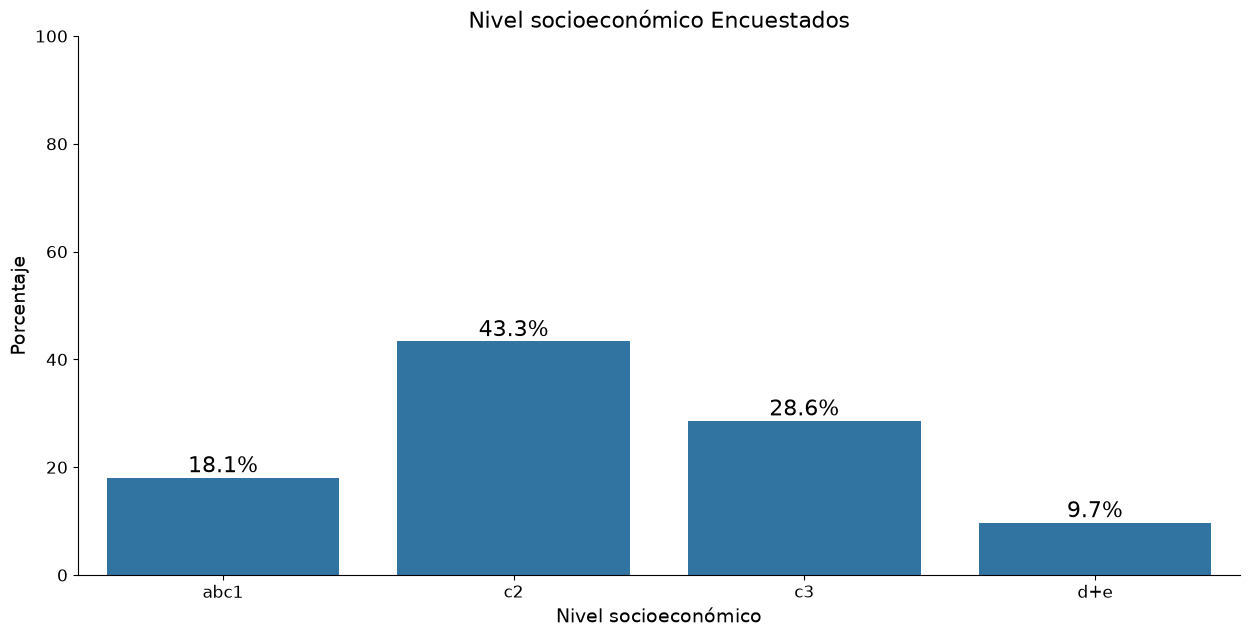

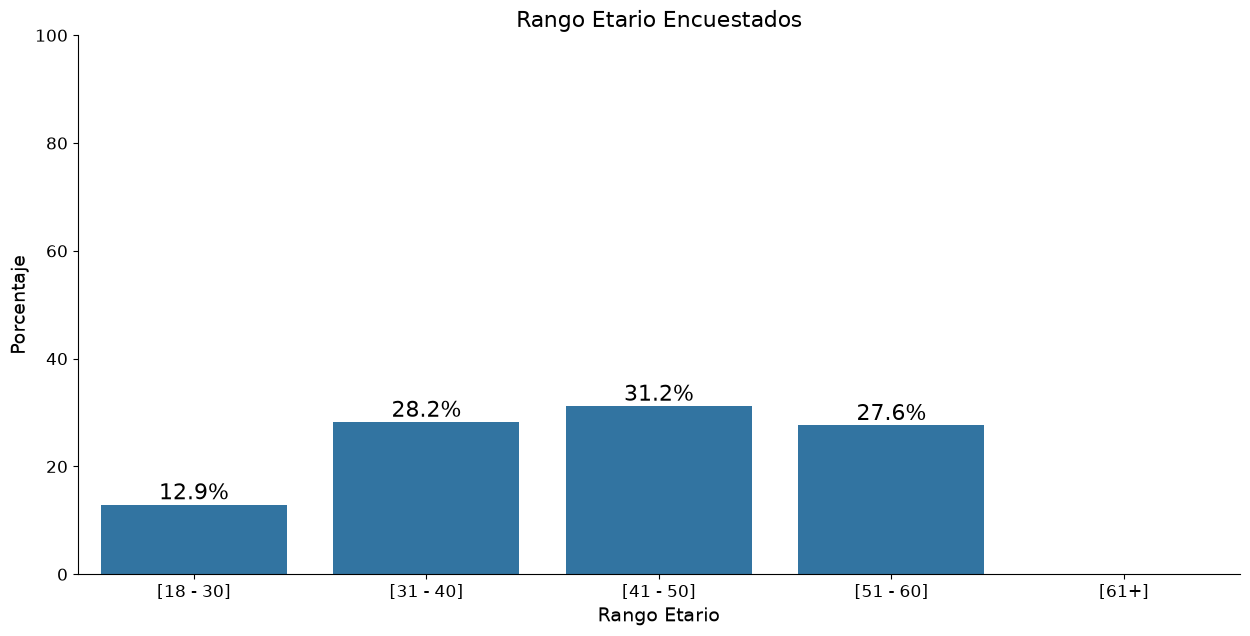

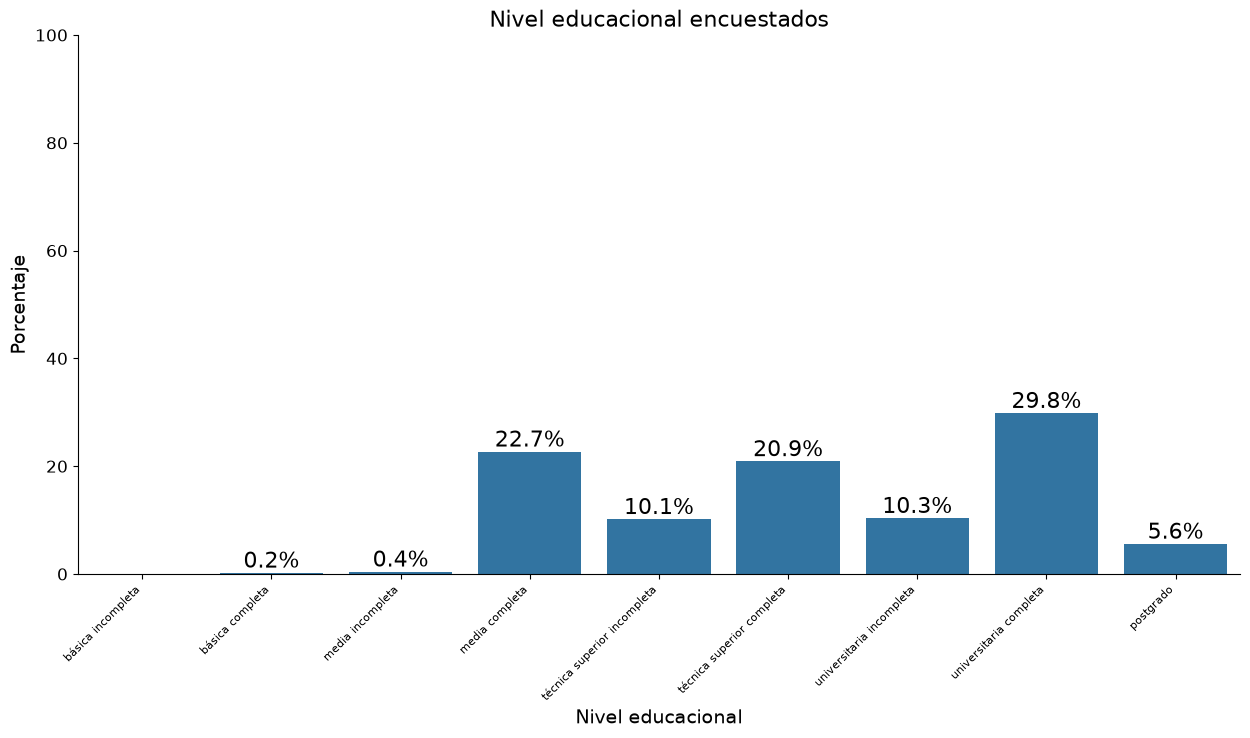

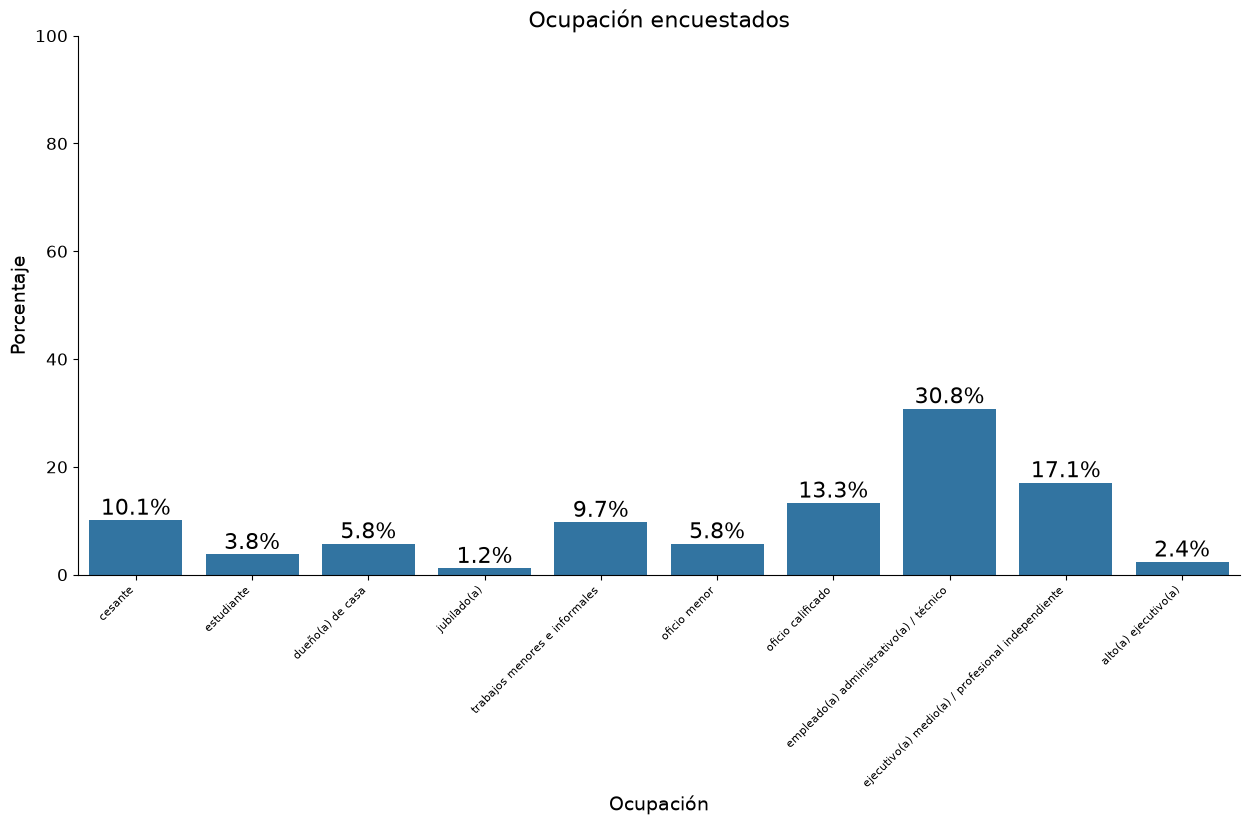

In [35]:
order_nse = ['abc1',
			 'c2',
			 'c3',
			 'd+e']

order_edad = ['[18 - 30]',
			'[31 - 40]',
			'[41 - 50]',
			'[51 - 60]',
			'[61+]'
			]

order_niveduc =['básica incompleta',
				'básica completa',
				'media incompleta',
				'media completa',
				'técnica superior incompleta',
				'técnica superior completa',
				'universitaria incompleta',
				'universitaria completa',
				'postgrado'
]

order_ocupacion= ['cesante',
				  'estudiante',
				  'dueño(a) de casa',
				  'jubilado(a)',
				  'trabajos menores e informales',
				  'oficio menor',
				  'oficio calificado',
				  'empleado(a) administrativo(a) / técnico',
				  'ejecutivo(a) medio(a) / profesional independiente',
				  'alto(a) ejecutivo(a)'
				  ]

# GRAFICO NSE
ax = sns.countplot(
	data=dfcomp,
	x='nse',
	stat='percent',
	order=order_nse
)

sns.despine()

# ax.containers[0] contiene el grupo de barras dibujadas
# bar_label agrega el valor de cada barra encima de ella
# fmt='%.1f%%' da formato con 1 decimal y el símbolo de porcentaje (ej: 23.4%)
ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
plt.xlabel('Nivel socioeconómico')
plt.ylim(0,100)
plt.title("Nivel socioeconómico Encuestados")
plt.show()

# GRAFICO EDAD
ax = sns.countplot(
	data=dfcomp,
	x='edad',
	stat='percent',
	order=order_edad
)

sns.despine()

# ax.containers[0] contiene el grupo de barras dibujadas
# bar_label agrega el valor de cada barra encima de ella
# fmt='%.1f%%' da formato con 1 decimal y el símbolo de porcentaje (ej: 23.4%)
ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
plt.xlabel('Rango Etario')
plt.ylim(0,100)
plt.title("Rango Etario Encuestados")
plt.show()

# GRAFICO NIVEDUC
ax = sns.countplot(
	data=dfcomp,
	x='niveduc',
	stat='percent',
	order=order_niveduc
)

sns.despine()

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
plt.xlabel('Nivel educacional')
plt.ylim(0,100)
plt.title("Nivel educacional encuestados")
plt.xticks(rotation=45, ha='right', fontsize='8')
plt.show()

# GRAFICO OCUPACION
ax = sns.countplot(
	data=dfcomp,
	x='ocupacion',
	stat='percent',
	order=order_ocupacion
)

sns.despine()

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
plt.xlabel('Ocupación')
plt.ylim(0,100)
plt.title("Ocupación encuestados")
plt.xticks(rotation=45, ha='right', fontsize='8' )
plt.show()


Series([], Name: count, dtype: int64)

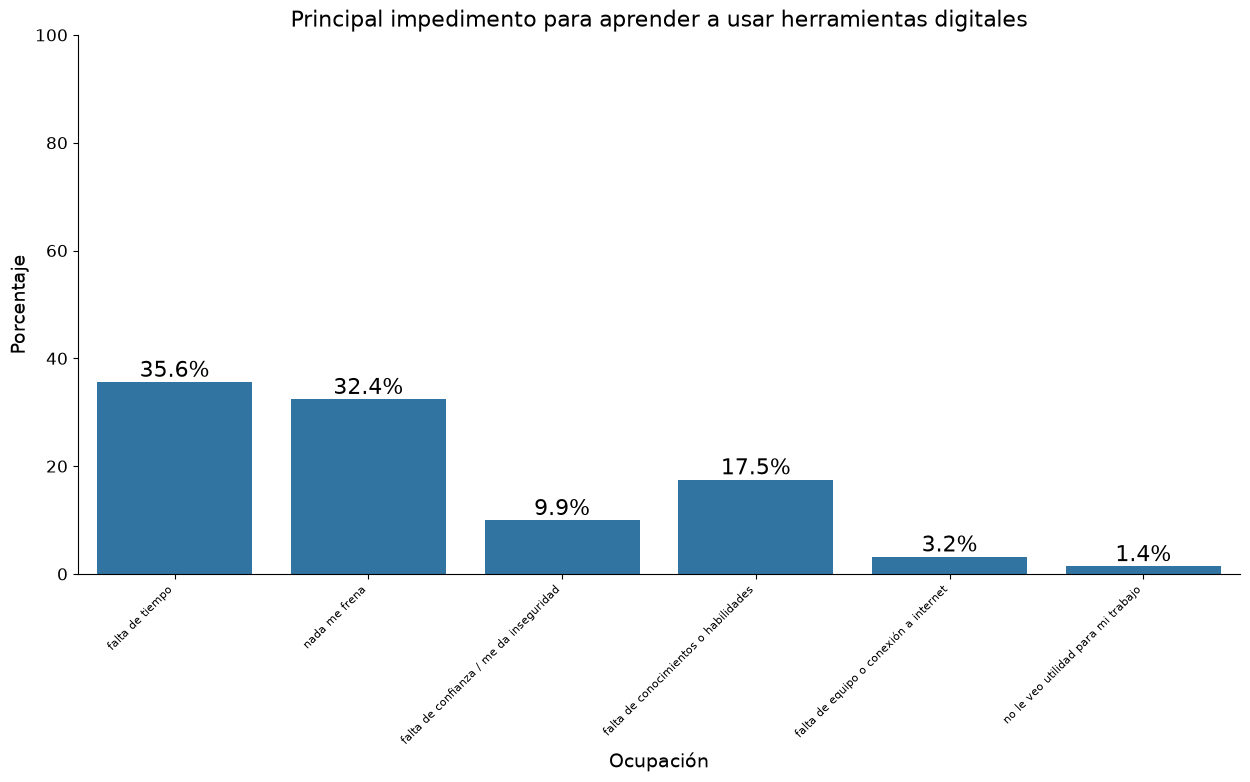

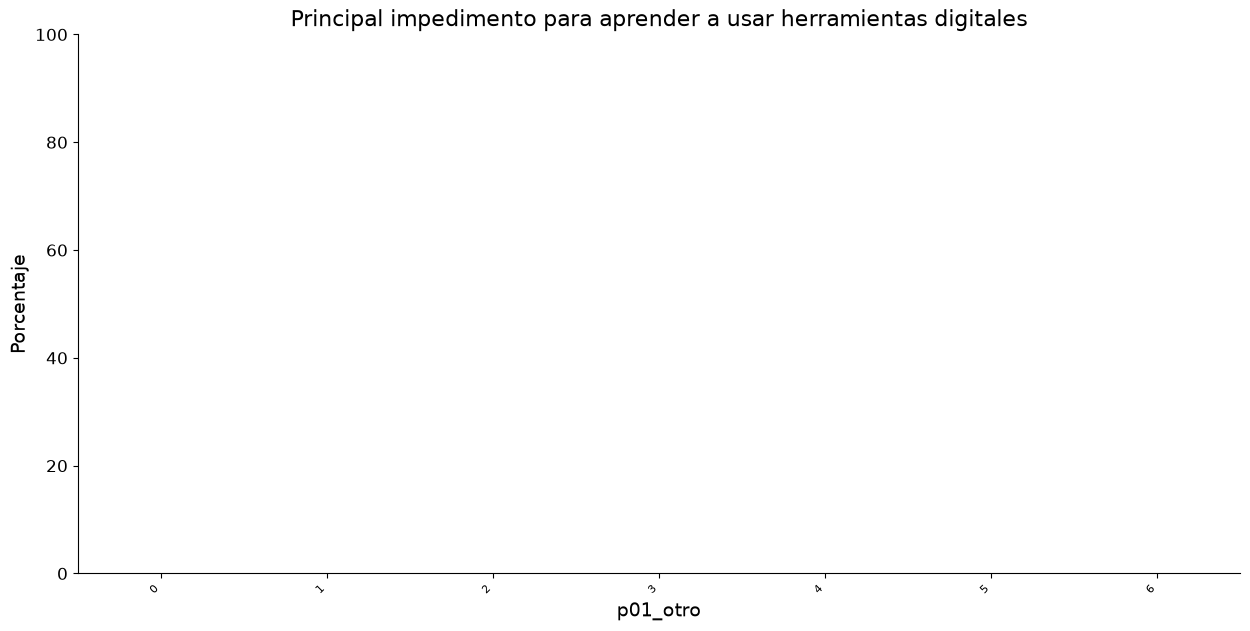

In [37]:
ax = sns.countplot(
	data=dfcomp,
	x='p01',
	stat='percent',
)

sns.despine()

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
plt.xlabel('Ocupación')
plt.ylim(0,100)
plt.title("Principal impedimento para aprender a usar herramientas digitales")
plt.xticks(rotation=45, ha='right', fontsize='8')
plt.show()

ax = sns.countplot(
	data=dfcomp,
	x='p01_otro',
	stat='percent',
)

sns.despine()

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
#plt.xlabel('Ocupación')
plt.ylim(0,100)
plt.title("Principal impedimento para aprender a usar herramientas digitales")
plt.xticks(rotation=45, ha='right', fontsize='8')
plt.show()

In [41]:
dfcomp['p02_otro'].value_counts()

Series([], Name: count, dtype: int64)